In [3]:
# Pandas ek library hai jo data (tables/excel) ko handle karne ke kaam aati hai
import pandas as pd

# Apni excel file ka exact naam yahan likho (agar naam alag hai toh change kar lena)
file_name = 'PCOS_data_without_infertility.xlsx' 

# Excel file ko read karke 'df' naam ke variable (table) mein save kar rahe hain
# (Sheet name kabhi kabhi "Full_new" hoti hai Kaggle dataset mein)
try:
    df = pd.read_excel(file_name, sheet_name="Full_new")
except:
    df = pd.read_excel(file_name)

# Dataset mein kitni rows aur columns hain, ye check karte hain
print("Dataset Shape (Rows, Columns):", df.shape)

# Table ki shuru ki 5 rows display karne ke liye
df.head()

Dataset Shape (Rows, Columns): (541, 45)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [4]:
# Hum sirf wahi columns select kar rahe hain jo humari app collect karegi
# Kaggle dataset mein kuch columns ke naam mein aage-peeche spaces hain, isliye exact spelling zaroori hai
selected_columns = [
    'PCOS (Y/N)',           # YEH HUMARA TARGET HAI (Predict karna hai)
    ' Age (yrs)',           # Age
    'Weight (Kg)',          # Weight
    'BMI',                  # BMI
    'Cycle(R/I)',           # Cycle Regular(2) ya Irregular(4)
    'Cycle length(days)',   # Cycle kitne din ki hai
    'Weight gain(Y/N)',     # Symptom
    'hair growth(Y/N)',     # Symptom (Facial/body hair)
    'Skin darkening (Y/N)', # Symptom
    'Hair loss(Y/N)',       # Symptom (Hair fall)
    'Pimples(Y/N)',         # Symptom (Acne)
    'Fast food (Y/N)',      # Lifestyle (Diet)
    'Reg.Exercise(Y/N)'     # Lifestyle (Activity)
]

# Naya filtered dataset banate hain
df_app = df[selected_columns].copy()

# Ab check karte hain ki kya inme koi 'Missing Data' (khali dabbe) hain?
print("Missing values in our app dataset:\n")
print(df_app.isnull().sum())

# Filtered data ka preview
df_app.head()

Missing values in our app dataset:

PCOS (Y/N)              0
 Age (yrs)              0
Weight (Kg)             0
BMI                     0
Cycle(R/I)              0
Cycle length(days)      0
Weight gain(Y/N)        0
hair growth(Y/N)        0
Skin darkening (Y/N)    0
Hair loss(Y/N)          0
Pimples(Y/N)            0
Fast food (Y/N)         1
Reg.Exercise(Y/N)       0
dtype: int64


,PCOS (Y/N),Age (yrs),Weight (Kg),BMI,Cycle(R/I),Cycle length(days),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N)
0,0,28,44.6,19.300000,2,5,0,0,0,0,0,1.0,0
1,0,36,65.0,24.921163,2,5,0,0,0,0,0,0.0,0
2,1,33,68.8,25.270891,2,5,0,0,0,1,1,1.0,0
3,0,37,65.0,29.674945,2,5,0,0,0,0,0,0.0,0
4,0,25,52.0,20.060954,2,5,0,0,0,1,0,0.0,0


In [5]:
# 1. Missing value fill karna
# Fast food column mein jo khali jagah hai, use hum sabse common answer (mode) se bhar rahe hain
df_app['Fast food (Y/N)'] = df_app['Fast food (Y/N)'].fillna(df_app['Fast food (Y/N)'].mode()[0])

# 2. Decimals (Float) ko normal number (Integer) mein convert karna
df_app['Fast food (Y/N)'] = df_app['Fast food (Y/N)'].astype(int)

# 3. Cycle(R/I) ko standardize karna (2 -> 0, 4 -> 1)
df_app['Cycle(R/I)'] = df_app['Cycle(R/I)'].map({2: 0, 4: 1})

# Ab ek baar final clean data dekhte hain
print("Missing values after cleaning:\n", df_app.isnull().sum())
print("\nCleaned Data Preview:")
df_app.head()

Missing values after cleaning:
 PCOS (Y/N)              0
 Age (yrs)              0
Weight (Kg)             0
BMI                     0
Cycle(R/I)              1
Cycle length(days)      0
Weight gain(Y/N)        0
hair growth(Y/N)        0
Skin darkening (Y/N)    0
Hair loss(Y/N)          0
Pimples(Y/N)            0
Fast food (Y/N)         0
Reg.Exercise(Y/N)       0
dtype: int64

Cleaned Data Preview:


,PCOS (Y/N),Age (yrs),Weight (Kg),BMI,Cycle(R/I),Cycle length(days),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N)
0,0,28,44.6,19.300000,0.0,5,0,0,0,0,0,1,0
1,0,36,65.0,24.921163,0.0,5,0,0,0,0,0,0,0
2,1,33,68.8,25.270891,0.0,5,0,0,0,1,1,1,0
3,0,37,65.0,29.674945,0.0,5,0,0,0,0,0,0,0
4,0,25,52.0,20.060954,0.0,5,0,0,0,1,0,0,0


In [6]:
# scikit-learn library se data split karne wala tool import kar rahe hain
from sklearn.model_selection import train_test_split

# 1. X aur Y define karna
# X ke liye hum 'PCOS (Y/N)' wale column ko hata denge, kyunki wo toh answer hai
X = df_app.drop('PCOS (Y/N)', axis=1)

# Y ke liye hum sirf 'PCOS (Y/N)' wala column rakhnge
y = df_app['PCOS (Y/N)']

# 2. Data ko Train (80%) aur Test (20%) mein split karna
# random_state=42 isliye likhte hain taaki jab bhi code run ho, data same tarike se split ho
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ab check karte hain ki training aur testing ke liye kitni rows aayi hain
print("Training Data size (X_train):", X_train.shape)
print("Testing Data size (X_test):", X_test.shape)

Training Data size (X_train): (432, 12)
Testing Data size (X_test): (109, 12)


In [7]:
import xgboost as xgb
import joblib
from sklearn.metrics import accuracy_score, classification_report

# 1. XGBoost model initialize karna
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# 2. Model ko Train karna (Padhana)
print("Training the XGBoost model...")
model.fit(X_train, y_train)
print("Training complete! ✅\n")

# 3. Model ka Test (Exam) lena (Yahan rf_model hata kar model kar diya hai)
y_pred = model.predict(X_test)

# 4. Result / Report Card check karna
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

print("Detailed Report Card (Classification Report):")
print(classification_report(y_test, y_pred))

# 5. Model ko aage ke liye save karna (Sab check karne ke baad last mein)
joblib.dump(model, 'xgboost_model.pkl')
print("Model saved successfully as xgboost_model.pkl!")

Training the XGBoost model...


C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [10:05:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training complete! ✅

Model Accuracy: 80.73%

Detailed Report Card (Classification Report):
              precision    recall  f1-score   support

           0       0.82      0.94      0.87        77
           1       0.76      0.50      0.60        32

    accuracy                           0.81       109
   macro avg       0.79      0.72      0.74       109
weighted avg       0.80      0.81      0.79       109

Model saved successfully as xgboost_model.pkl!


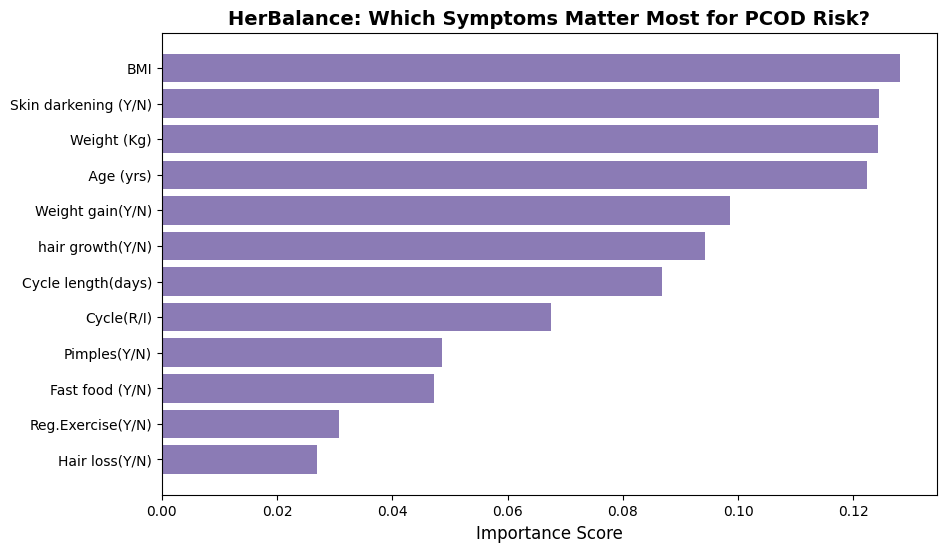

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Model se puchna ki kaunsa symptom sabse zyada important tha
importances = rf_model.feature_importances_
features = X.columns

# Ise ek table mein arrange karna
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Graph plot karna (HerBalance app ke purple theme color mein)
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='#8B7BB5')
plt.gca().invert_yaxis() # Sabse important feature ko top par rakhne ke liye
plt.title('HerBalance: Which Symptoms Matter Most for PCOD Risk?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.show()

In [7]:
import joblib

# Model ko save karne ka naam decide kar rahe hain
model_filename = 'pcod_rf_model.pkl'

# Trained model ko save kar rahe hain
joblib.dump(rf_model, model_filename)

print(f"Model successfully saved as {model_filename}! 🎉")

Model successfully saved as pcod_rf_model.pkl! 🎉
